In [1]:
%load_ext autoreload
%autoreload 2

#### Optimize the Synchronous Buck Converter with Single-Objective MHA
 * Objective: Maximize efficiency
 * Constraint: Size of inductor and capacitor
 * Design variables: Inductance L and capacitance C values
 * In this example, analytical efficiency formulas are adopted in the objective function 

##### 1 Define Performance and Constraint when Optimizing the Buck Converter

In [2]:
import numpy as np
import pyswarms as ps
import matplotlib.pyplot as plt
from matplotlib import animation

def buck_converter_losses(L, C, Io, inductanceR, capacitorR):
    """
    Calculate various losses and parameters for a synchronous buck converter.

    Parameters:
    - L: Inductance (H)
    - C: Capacitance (F)
    - Io: Output current (A)
    - inductanceR: function, returns copper resistance of inductor given L
    - capacitorR: function, returns ESR of capacitor given C, Vo

    Returns:
    - dict of all calculated losses and key parameters
    """
    import numpy as np
    from scipy.integrate import quad

    # Define key parameters for the synchronous buck converter
    f = 1e4            # Switching frequency (Hz)
    QG = 62e-9         # Gate charge (Coulombs)
    Vgs = 20           # Gate-source voltage (V)
    Coss = 475e-12     # Output capacitance of MOSFET (Farads)
    Vin = 100          # Input voltage (V)
    Vds = Vin          # Drain-source voltage (V)
    Ron = 75e-3        # On-resistance of MOSFET (Ohms)
    Vo = 50            # Output voltage (V)

    # Inductor geometry parameters
    OD = 28.6e-3       # Outer diameter of inductor (meters)
    ID = 11.8e-3       # Inner diameter of inductor (meters)
    H = 10e-3          # Height of inductor (meters)
    ur = 49            # Relative permeability of core material

    # Calculate effective core volume and area
    Ve = (38.92*L*1e6+264.3)*1e-3           # Effective core volume (m^3)
    AeN = (13.26*L*1e6+1008)*1e-9*1e3/0.6   # Effective core area (m^2)
    Ro = Vo/Io

    # Steinmetz parameters for core loss calculation
    kc = 3.961*1e-9
    afa = 1.214
    beta = 2.013

    # Calculate copper resistance of the inductor
    DCR = inductanceR(L)
    Rcopper = DCR

    # MOSFET switching times
    tr = 37e-9
    tf = 38e-9

    # Mosfet reverse recovery charge (for reverse recovery loss)
    Qcoss = 152e-9
    Qrr = 152e-9  # Example value, adjust as needed

    # Capacitor equivalent series resistance
    ESR = capacitorR(C, f)

    # Calculate the duty cycle
    D = Vo/Vin * (1+Rcopper/Ro)

    # Calculate intermediate variables
    A = (Vin-Vo)/Rcopper
    B = Vo/Rcopper
    E = np.exp(-Rcopper/L*D/f)

    # Calculate the inductor current
    # (as in the original code)
    ILmin = 2*Io/(1+E)-A*(1-E)/(1+E)
    ILmax = 2*Io-ILmin

    # t1, t2 for integration limits
    try:
        t1 = -L/DCR * np.log((Io-A)/(ILmin-A))
    except:
        t1 = 0
    try:
        t2 = -L/DCR * np.log((Io+B)/(ILmax+B))
    except:
        t2 = 0

    # Define integrands for INTEGRALL, INTEGRALL2, INTEGRALL3
    def integrand1a(x):
        return A**2 + 2*A*(ILmin-A)*np.exp(-DCR/L*x) + (ILmin-A)**2 * np.exp(-2*DCR/L*x)
    def integrand1b(x):
        return B**2 - 2*B*(ILmax+B)*np.exp(-DCR/L*x) + (ILmax+B)**2 * np.exp(-2*DCR/L*x)
    def integrand2a(x):
        return A + (ILmin-A)*np.exp(-DCR/L*x)
    def integrand2b(x):
        return -B + (ILmax+B)*np.exp(-DCR/L*x)
    def integrand3a(x):
        return A + (ILmin-A)*np.exp(-DCR/L*x)
    def integrand3b(x):
        return -B + (ILmax+B)*np.exp(-DCR/L*x)

    # Perform integrations
    INTEGRALL, _ = quad(integrand1a, 0, D/f)
    temp, _ = quad(integrand1b, 0, (1-D)/f)
    INTEGRALL += temp

    INTEGRALL2, _ = quad(integrand2a, 0, D/f)
    temp, _ = quad(integrand2b, 0, (1-D)/f)
    INTEGRALL2 += temp

    INTEGRALL3, _ = quad(integrand3a, t1, D/f)
    temp, _ = quad(integrand3b, 0, t2)
    INTEGRALL3 += temp

    # 1. Gate drive loss
    Pdr = QG * Vgs * f

    # 2. Output capacitance loss of MOSFET
    Pcoss = 0.5 * Coss * Vds**2 * f

    # 3. Conduction loss of MOSFET
    Pon = Ron * f * INTEGRALL

    # 4. Inductor current ripple
    deltaI = ILmax - ILmin

    # 5. Core flux density swing
    deltaB = L * deltaI / AeN

    # 6. Steinmetz equation for core loss
    ki = kc * 2**(-beta-1) * np.pi**(1-afa) / (0.2761 + 1.7061 / (1.354 + afa))
    Pfe = ki * (deltaB*1e4)**beta * f**afa * (D**(1-afa) + (1-D)**(1-afa)) * Ve * 1e-3

    # 7. Copper loss in the inductor
    Pcu = DCR * f * INTEGRALL

    # 8. Minimum and maximum inductor current (already calculated above)

    # 9. MOSFET switching losses
    Pswitchon = 0.5*Vin * Io * tr * f
    Pswitchoff = 0.5*Vin * Io * tf * f

    # 9b. Reverse recovery loss
    Prr = Qrr * Vds * f

    # 10. Capacitor ESR loss
    PC = ESR * f * INTEGRALL - ESR * f * 2 * Io * INTEGRALL2 + ESR * Io**2

    # 11. Total power loss (add Prr)
    Ptotal = 2*Pdr + Pon + Pfe + Pcu + Pswitchon + Pswitchoff + Prr + PC

    # Voltage ripple and current ripple
    voltageripple = ((INTEGRALL3 - Io * (t2 + D/f - t1)) / C + ESR * deltaI) / Vo
    currentripple = deltaI / Io

    return {
        'Pdr': Pdr,
        'Pcoss': Pcoss,
        'Pon': Pon,
        'deltaI': deltaI,
        'deltaB': deltaB,
        'Pfe': Pfe,
        'Pcu': Pcu,
        'ILmin': ILmin,
        'ILmax': ILmax,
        'Pswitchon': Pswitchon,
        'Pswitchoff': Pswitchoff,
        'Prr': Prr,
        'PC': PC,
        'Ptotal': Ptotal,
        'N': None,
        'Ve': Ve,
        'Rcopper': Rcopper,
        'ESR': ESR,
        'D': D,
        'Vo': Vo,
        'Vin': Vin,
        'f': f,
        'voltageripple': voltageripple,
        'currentripple': currentripple
    }

def evaluate_LC_volume(L, C):
    """
    Evaluate the total volume of inductor (L) and capacitor (C).

    Parameters:
    L (float): Inductance in Henrys
    C (float): Capacitance in Farads

    Returns:
    float: Total volume (y) in mm^3
    """
    a_C = 5.909
    b_C = 0
    a_L = 38.92
    b_L = 264.3

    VC = a_C * C * 1e6 + b_C
    VL = a_L * L * 1e6 + b_L
    y = VC + VL
    return y


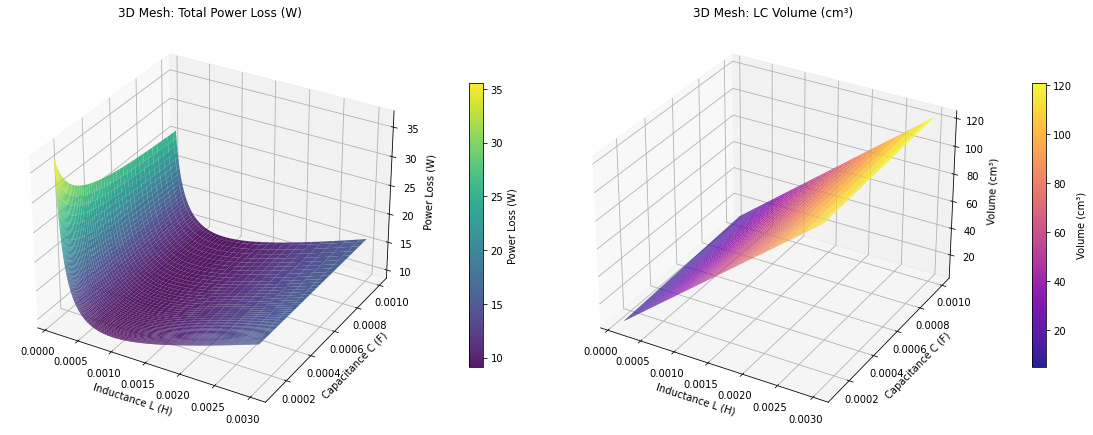

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Define the ranges for L and C
L_vals = np.logspace(np.log10(100e-6), np.log10(3e-3), 100)
C_vals = np.logspace(np.log10(100e-6), np.log10(1e-3), 100)
L_grid, C_grid = np.meshgrid(L_vals, C_vals)

# Define dummy functions for inductor copper resistance and capacitor ESR
def inductanceR(L):
    # Example: assume copper resistance is proportional to sqrt(L)
    return 1183*L+0.01034

def capacitorR(C, f):
    # Example: assume ESR is inversely proportional to C
    return 1.5 / (2 * np.pi * f * C)

Io = 2  # Output current in A

Ptotal_grid = np.zeros_like(L_grid)
Volume_grid = np.zeros_like(L_grid)

for i in range(L_grid.shape[0]):
    for j in range(L_grid.shape[1]):
        L = L_grid[i, j]
        C = C_grid[i, j]
        try:
            result = buck_converter_losses(L, C, Io, inductanceR, capacitorR)
            Ptotal_grid[i, j] = result['Ptotal']
        except Exception:
            Ptotal_grid[i, j] = np.nan
        try:
            Volume_grid[i, j] = evaluate_LC_volume(L, C)
        except Exception:
            Volume_grid[i, j] = np.nan

# Plot the function landscapes as 2D surface plots with colorbars (no log scale for L and C)

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Assume L_grid, C_grid, Ptotal_grid, Volume_grid are defined earlier

fig = plt.figure(figsize=(16, 6))

# 3D Mesh for Total Power Loss
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf1 = ax1.plot_surface(L_grid, C_grid, Ptotal_grid, cmap='viridis', edgecolor='none', alpha=0.9)
ax1.set_xlabel('Inductance L (H)')
ax1.set_ylabel('Capacitance C (F)')
ax1.set_zlabel('Power Loss (W)')
ax1.set_title('3D Mesh: Total Power Loss (W)')
fig.colorbar(surf1, ax=ax1, shrink=0.7, pad=0.1, label='Power Loss (W)')

# 3D Mesh for Volume
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
# Convert Volume_grid from mm³ to cm³ (1 cm³ = 1000 mm³)
Volume_grid_cm3 = Volume_grid / 1000.0
surf2 = ax2.plot_surface(L_grid, C_grid, Volume_grid_cm3, cmap='plasma', edgecolor='none', alpha=0.9)
ax2.set_xlabel('Inductance L (H)')
ax2.set_ylabel('Capacitance C (F)')
ax2.set_zlabel('Volume (cm³)')
ax2.set_title('3D Mesh: LC Volume (cm³)')
fig.colorbar(surf2, ax=ax2, shrink=0.7, pad=0.1, label='Volume (cm³)')

plt.tight_layout()
plt.show()




##### 2 Define Objective Function for Particle Swarm Optimization

In [4]:
def objective_function(x, penalty_factor=1e3):
    """
    Objective function for PSO.
    Minimizes total power loss, with a constraint on total volume.

    Parameters:
    x : np.ndarray
        Shape (n_particles, 2), where x[:,0] = L (H), x[:,1] = C (F)

    Returns:
    np.ndarray
        Objective values for each particle.
    """
    # Constraint: maximum allowed total volume (in cm^3)
    max_volume = 30  # example value, adjust as needed

    n_particles = x.shape[0]
    obj = np.zeros(n_particles)

    for i in range(n_particles):
        L = x[i, 0]
        C = x[i, 1]
        # Use global Io, inductanceR, capacitorR, buck_converter_losses, evaluate_LC_volume
        losses = buck_converter_losses(L, C, Io, inductanceR, capacitorR)
        volume = evaluate_LC_volume(L, C)/1000
        # Penalty if volume exceeds constraint
        penalty = 0.0
        if volume > max_volume:
            # Penalty is 1e6 if volume exceeds constraint
            penalty = penalty_factor * (volume - max_volume)
        obj[i] = losses['Ptotal'] + penalty

    return obj

# Example: Evaluate a specific case for L and C
L_test = 600e-6  # 100 uH
C_test = 220e-6  # 220 uF

x_test = np.array([[L_test, C_test]])
obj_val = objective_function(x_test)

print(f"Test case: L = {L_test} H, C = {C_test} F")
print(f"Objective value: {obj_val[0]}")


Test case: L = 0.0006 H, C = 0.00022 F
Objective value: 9.682287098702574


Iteration 1/100, inertia w=0.9000, best cost=16.094367
Iteration 2/100, inertia w=0.8919, best cost=9.784961
Iteration 3/100, inertia w=0.8838, best cost=9.429686
Iteration 4/100, inertia w=0.8758, best cost=9.429686
Iteration 5/100, inertia w=0.8677, best cost=9.429686
Iteration 6/100, inertia w=0.8596, best cost=9.356161
Iteration 7/100, inertia w=0.8515, best cost=9.287989
Iteration 8/100, inertia w=0.8434, best cost=9.287989
Iteration 9/100, inertia w=0.8354, best cost=9.287989
Iteration 10/100, inertia w=0.8273, best cost=9.287989
Iteration 11/100, inertia w=0.8192, best cost=9.287989
Iteration 12/100, inertia w=0.8111, best cost=9.287989
Iteration 13/100, inertia w=0.8030, best cost=9.287989
Iteration 14/100, inertia w=0.7949, best cost=9.287989
Iteration 15/100, inertia w=0.7869, best cost=9.287989
Iteration 16/100, inertia w=0.7788, best cost=9.287989
Iteration 17/100, inertia w=0.7707, best cost=9.287989
Iteration 18/100, inertia w=0.7626, best cost=9.287989
Iteration 19/100, 

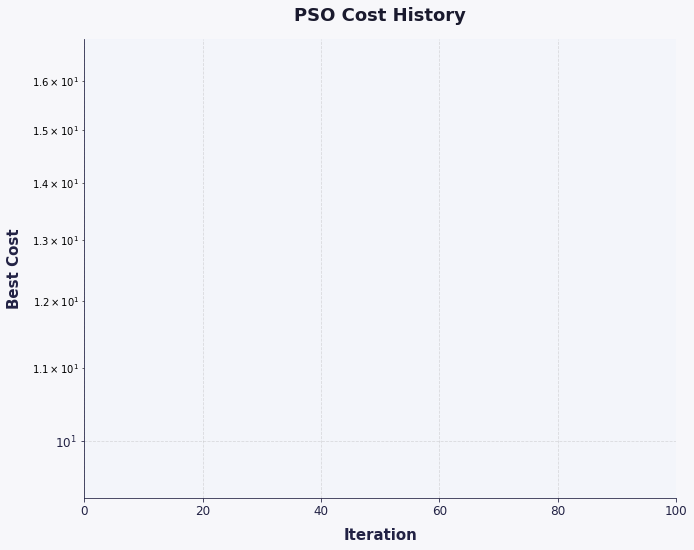

2026-03-16 21:10:17,562 - matplotlib.animation - INFO - Animation.save using <class 'matplotlib.animation.PillowWriter'>
2026-03-16 21:10:48,166 - matplotlib.animation - INFO - Animation.save using <class 'matplotlib.animation.PillowWriter'>
C:\Temp/ipykernel_24596/4190505501.py:209: MatplotlibDeprecationWarning: Setting data with a non sequence type is deprecated since 3.7 and will be remove two minor releases later
  gbest_point.set_data(gbest[0], gbest[1])


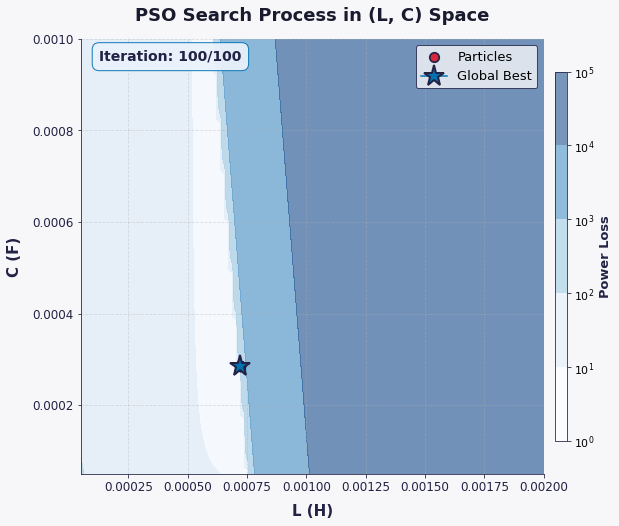

In [5]:
import numpy as np
import pyswarms as ps
import matplotlib.pyplot as plt
from matplotlib import animation

# --- PSO Hyperparameters ---
dimensions = 2
bounds = (
    np.array([50e-6, 50e-6]),      # Lower bounds: L, C
    np.array([2e-3, 1e-3])           # Upper bounds: L, C (in H and F)
)
n_particles = 10
iters = 100

# Inertia and acceleration coefficients (initial values)
c1 = 2.05
c2 = 2.05

velocity_clamp = (np.array([-2e-4, -2e-4]), np.array([2e-4, 2e-4]))

# We'll update 'w' (inertia) linearly from 0.9 to 0.1 over the iterations
w_max = 0.9
w_min = 0.1

options = {'c1': c1, 'c2': c2, 'w': w_max}  # initial w, will be updated each iteration

# --- History containers ---
positions_history = []
cost_history = []

# --- Custom objective for PSO (records positions and cost) ---
def pso_objective(X):
    # X shape: (n_particles, 2)
    cost = objective_function(X)
    # Record positions and best cost at this iteration
    positions_history.append(X.copy())
    cost_history.append(np.min(cost))
    return cost

# --- Set up PSO optimizer ---
optimizer = ps.single.GlobalBestPSO(
    n_particles=n_particles,
    dimensions=dimensions,
    options=options,
    bounds=bounds,
    velocity_clamp=velocity_clamp
)

# --- Custom PSO loop with linearly decreasing inertia ---
for i in range(iters):
    # Linearly decrease inertia weight from w_max to w_min
    w = w_max - (w_max - w_min) * (i / (iters - 1))
    optimizer.options['w'] = w
    cost, pos = optimizer.optimize(
        pso_objective,
        iters=1,
        verbose=False
    )
    # Optionally, print progress
    print(f"Iteration {i+1}/{iters}, inertia w={w:.4f}, best cost={cost:.6f}")

best_cost = cost
best_pos = pos

print(f"Best solution found: L = {best_pos[0]:.6f} H, C = {best_pos[1]:.6f} F")
print(f"Best cost: {best_cost:.6f}")
# Evaluate the losses and volume in cm3 for the optimal design
L_opt, C_opt = best_pos
cost_opt = best_cost
print(f"Best solution found: L = {L_opt:.6f} H, C = {C_opt:.6f} F")
print(f"Best cost: {cost_opt:.6f}")
losses = buck_converter_losses(L_opt, C_opt, Io, inductanceR, capacitorR)
print("total losses: ", losses['Ptotal'])
# Evaluate total volume in cm^3
volume_mm3 = evaluate_LC_volume(L_opt, C_opt)
volume_cm3 = volume_mm3 / 1000  # 1 cm^3 = 1000 mm^3
# print("\nDetailed losses for the optimal design:")
# for k, v in losses.items():
#     print(f"{k}: {v:.6g}")
print(f"\nTotal volume (L + C): {volume_cm3:.3f} cm³")


# --- Animation: Cost history over iterations (Styled) ---
fig1, ax1 = plt.subplots(figsize=(10, 8), facecolor='#f7f7fa')
# Style the axes
ax1.set_facecolor('#f7f7fa')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#222244')
ax1.spines['bottom'].set_color('#222244')
ax1.tick_params(axis='both', colors='#222244', labelsize=12)
ax1.set_xlabel('Iteration', fontsize=15, fontweight='bold', color='#222244', labelpad=10)
ax1.set_ylabel('Best Cost', fontsize=15, fontweight='bold', color='#222244', labelpad=10)
ax1.set_title('PSO Cost History', fontsize=18, fontweight='bold', color='#1a1a2e', pad=18)
ax1.grid(True, linestyle='--', alpha=0.4, color='#b0b0b0', zorder=0)
# Compute the best cost found so far at each iteration
best_so_far_cost = np.minimum.accumulate(cost_history)
ax1.set_xlim(0, len(best_so_far_cost))
min_cost = np.min(best_so_far_cost)
if min_cost <= 0:
    min_cost = 1e-12
ax1.set_yscale('log')
ax1.set_ylim(min_cost, np.max(best_so_far_cost)*1.05)
plt.tight_layout(pad=2.0)

# Add a background rectangle for style
rect = plt.Rectangle(
    (0, min_cost), len(best_so_far_cost), np.max(best_so_far_cost)*1.05-min_cost,
    color='#eaf2fb', alpha=0.25, zorder=0
)
ax1.add_patch(rect)

# Add a shadow effect for the line
line1, = ax1.plot([], [], linewidth=4, color='#0072B2', alpha=0.95, zorder=3, solid_capstyle='round')
shadow1, = ax1.plot([], [], linewidth=8, color='#b0b0b0', alpha=0.18, zorder=2, solid_capstyle='round')

def init_cost():
    line1.set_data([], [])
    shadow1.set_data([], [])
    return line1, shadow1

def animate_cost(i):
    x = np.arange(i+1)
    y = best_so_far_cost[:i+1]
    line1.set_data(x, y)
    shadow1.set_data(x, y)
    return line1, shadow1

ani_cost = animation.FuncAnimation(
    fig1, animate_cost, frames=len(best_so_far_cost), init_func=init_cost,
    blit=True, interval=200, repeat=False
)

plt.show()
ani_cost.save('buck_pso_cost_history.gif', writer='pillow', fps=5)

# --- Animation: PSO search process in (L, C) space (Styled, with mesh) ---
def create_pso_animation(positions_history, bounds, iters, filename='buck_pso_search.gif', fps=5):
    fig, ax = plt.subplots(figsize=(10, 8), facecolor='#f7f7fa')
    ax.set_facecolor('#f7f7fa')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#222244')
    ax.spines['bottom'].set_color('#222244')
    ax.tick_params(axis='both', colors='#222244', labelsize=12)
    ax.set_xlim(bounds[0][0], bounds[1][0])
    ax.set_ylim(bounds[0][1], bounds[1][1])
    ax.set_xlabel('L (H)', fontsize=15, fontweight='bold', color='#222244', labelpad=10)
    ax.set_ylabel('C (F)', fontsize=15, fontweight='bold', color='#222244', labelpad=10)
    ax.set_title('PSO Search Process in (L, C) Space', fontsize=18, fontweight='bold', color='#1a1a2e', pad=18)
    ax.grid(True, linestyle='--', alpha=0.4, color='#b0b0b0', zorder=0)

    # Add a subtle background rectangle
    rect = plt.Rectangle(
        (bounds[0][0], bounds[0][1]),
        bounds[1][0] - bounds[0][0],
        bounds[1][1] - bounds[0][1],
        color='#eaf2fb', alpha=0.22, zorder=0
    )
    ax.add_patch(rect)

    # --- Plot mesh for power loss (contourf) ---
    # Create a meshgrid for L and C
    L_vals = np.linspace(bounds[0][0], bounds[1][0], 120)
    C_vals = np.linspace(bounds[0][1], bounds[1][1], 120)
    LL, CC = np.meshgrid(L_vals, C_vals)
    mesh_points = np.stack([LL.ravel(), CC.ravel()], axis=1)
    # Evaluate power loss (objective function) at each mesh point
    mesh_loss = objective_function(mesh_points).reshape(LL.shape)
    # Use a nice colormap and log scale for loss
    mesh = ax.contourf(
        LL, CC, mesh_loss, 
        levels=30, 
        cmap='Blues', 
        alpha=0.55, 
        zorder=1,
        norm=plt.matplotlib.colors.LogNorm(vmin=np.nanmin(mesh_loss[mesh_loss>0]), vmax=np.nanmax(mesh_loss))
    )
    # Add a colorbar for the mesh
    cbar = fig.colorbar(mesh, ax=ax, pad=0.02, aspect=30, shrink=0.85)
    cbar.set_label('Power Loss', fontsize=13, color='#222244', fontweight='bold')
    cbar.ax.yaxis.set_tick_params(color='#222244', labelsize=11)
    cbar.outline.set_edgecolor('#222244')

    # Particle and global best styling
    scat = ax.scatter([], [], c='#D7263D', s=90, edgecolor='#222244', linewidth=1.7, label='Particles', zorder=4)
    gbest_point, = ax.plot([], [], marker='*', color='#0072B2', markersize=22, markeredgecolor='#222244', markeredgewidth=2, label='Global Best', zorder=5)
    ax.legend(loc='upper right', fontsize=13, frameon=True, facecolor='#f7f7fa', edgecolor='#222244')

    iteration_text = ax.text(
        0.04, 0.95, "", transform=ax.transAxes, fontsize=14, fontweight='bold', color='#222244',
        bbox=dict(boxstyle="round,pad=0.5", edgecolor='#0072B2', facecolor='#eaf2fb', alpha=0.92)
    )

    def init():
        scat.set_offsets(np.empty((0, 2)))
        gbest_point.set_data([], [])
        iteration_text.set_text("")
        return scat, gbest_point, iteration_text

    def animate(i):
        pos = positions_history[i]
        scat.set_offsets(pos)
        # Find global best so far
        all_positions = np.vstack(positions_history[:i+1])
        all_costs = np.hstack([objective_function(p) for p in positions_history[:i+1]])
        idx = np.argmin(all_costs)
        gbest = all_positions[idx]
        gbest_point.set_data(gbest[0], gbest[1])
        iteration_text.set_text(f"Iteration: {i+1}/{iters}")
        return scat, gbest_point, iteration_text

    ani = animation.FuncAnimation(
        fig, animate, frames=len(positions_history),
        init_func=init, blit=True, interval=1000//fps, repeat=False
    )

    ani.save(filename, writer='pillow', fps=fps)
    plt.show()
    return ani

create_pso_animation(positions_history, bounds, iters)
